In [21]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [23]:
train_dir = r"C:\Users\hp\Downloads\Cleaned dataset\Train"
val_dir = r"C:\Users\hp\Downloads\Cleaned dataset\Val"


In [25]:
IMG_SIZE = (224, 224)  # Image size for ResNet50
BATCH_SIZE = 32  # Number of images per batch

# Only rescaling (since data is already augmented)
train_datagen = ImageDataGenerator(rescale=1.0/255)
val_datagen = ImageDataGenerator(rescale=1.0/255)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)


Found 4458 images belonging to 4 classes.
Found 512 images belonging to 4 classes.


In [27]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers to keep pretrained features
base_model.trainable = False

x = Flatten()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
output = Dense(4, activation="softmax")(x)  # 4 output classes

# Define the final model
model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 36,441,412 (139.01 MB)

 Trainable params: 12,853,700 (49.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

model.save("resnet50_brain_tumor_model.h5")


E:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
 28/140 ━━━━━━━━━━━━━━━━━━━━ 6:40 4s/step - accuracy: 0.3590 - loss: 4.5753

In [11]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc:.2f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.7770 - loss: 0.7540
Validation Accuracy: 0.77


In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for model input

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    
    class_labels = train_generator.class_indices
    class_labels = {v: k for k, v in class_labels.items()}  # Reverse dictionary
    
    print(f"Predicted Tumor Type: {class_labels[class_index]}")

# Example usage:
predict_image("gg (10).jpg")
predict_image("m (12).jpg")
predict_image("p (691).jpg")
predict_image("image(17).jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Predicted Tumor Type: Meningioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Predicted Tumor Type: Meningioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Predicted Tumor Type: Pituitary
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
Predicted Tumor Type: No Tumor


In [15]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc:.2f}")
print(f"Validation Loss: {val_loss:.2f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.7976 - loss: 0.6458
Validation Accuracy: 0.77
Validation Loss: 0.73


16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step


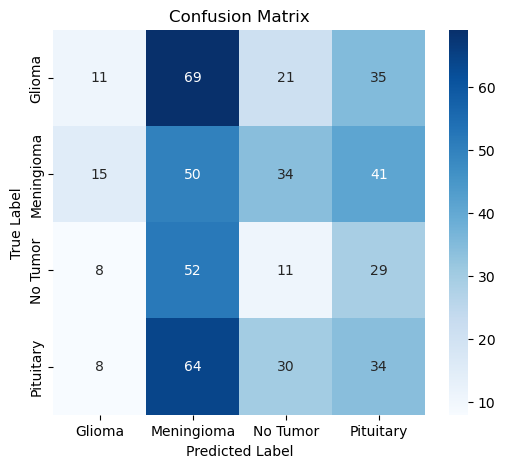

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get true labels and predictions
true_labels = val_generator.classes
predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=val_generator.class_indices, yticklabels=val_generator.class_indices)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [19]:
from sklearn.metrics import classification_report

report = classification_report(true_labels, predicted_classes, target_names=val_generator.class_indices)
print(report)


              precision    recall  f1-score   support

      Glioma       0.26      0.08      0.12       136
  Meningioma       0.21      0.36      0.27       140
    No Tumor       0.11      0.11      0.11       100
   Pituitary       0.24      0.25      0.25       136

    accuracy                           0.21       512
   macro avg       0.21      0.20      0.19       512
weighted avg       0.22      0.21      0.19       512



In [3]:
from sklearn.metrics import roc_curve, auc

# Convert true labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
true_labels_one_hot = to_categorical(true_labels, num_classes=4)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
for i in range(4):  # 4 classes
    fpr, tpr, _ = roc_curve(true_labels_one_hot[:, i], predictions[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], "k--")  # Random guessing line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


NameError: name 'true_labels' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy & loss values
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)  # X-axis (Epochs)

# Plot Accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)  # First plot (Accuracy)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)  # Second plot (Loss)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()


In [1]:
history = model.fit(train_generator, 
                    validation_data=val_generator, 
                    epochs=20)  # Adjust epochs as needed


NameError: name 'model' is not defined